In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, shapiro
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

In [6]:
df = pd.read_csv(r"Salary_dataset.csv")
df




,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [7]:
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')


df

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


In [8]:
print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes

Missing Values:
YearsExperience    0
Salary             0
dtype: int64


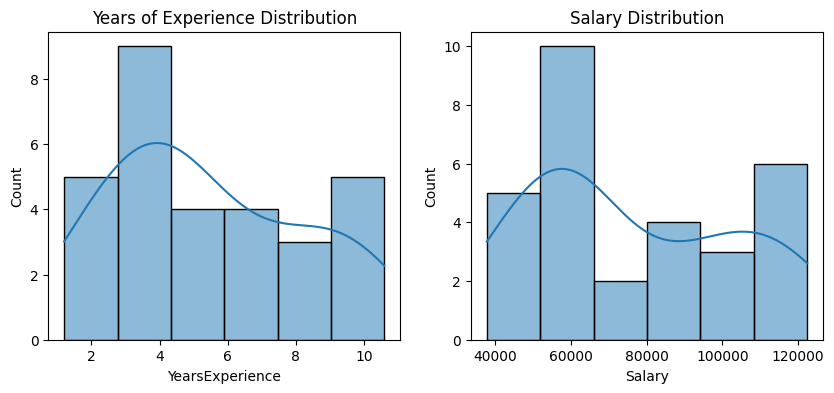

Skewness of YearsExperience: 0.36
Skewness of Salary: 0.34


In [9]:
# Step 4: Distribution & Skewness
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['YearsExperience'],kde=True)
plt.title("Years of Experience Distribution")

plt.subplot(1,2,2)
sns.histplot(df['Salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

print(f"Skewness of YearsExperience: {skew(df['YearsExperience']):.2f}")
print(f"Skewness of Salary: {skew(df['Salary']):.2f}")

Correlation between YearsExperience and Salary: 0.9782


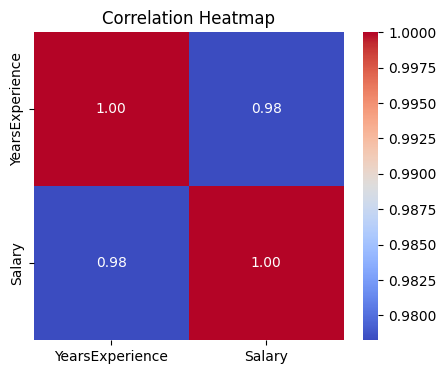

In [10]:
# Correlation Analysis
corr_value = df['YearsExperience'].corr(df['Salary'])
print(f"Correlation between YearsExperience and Salary: {corr_value:.4f}")

plt.figure(figsize=(5,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


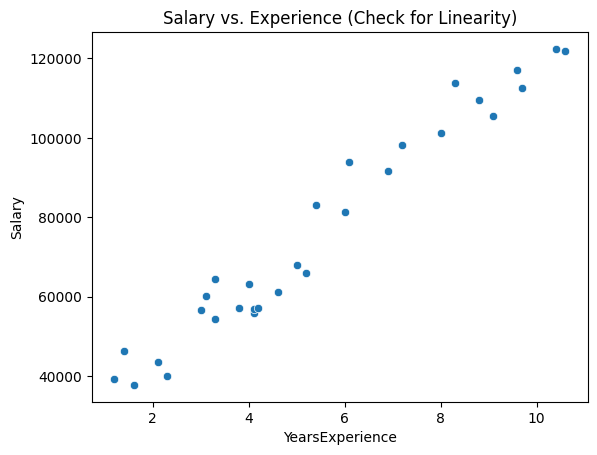

In [11]:
#step5: Scatterplot for Linear Relationship
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title("Salary vs. Experience (Check for Linearity)")
plt.show()


In [14]:
from sklearn.model_selection import train_test_split

# Prepare data for sklearn
X = df[['YearsExperience']].values
Y = df['Salary'].values

# 2. Split the data: 80% Training, 20% Testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Convert arrays back to DataFrames/Series for easy output
X_train_df = pd.DataFrame(X_train, columns=['YearsExperience'])
Y_train_series = pd.Series(Y_train, name='Salary')
X_test_df = pd.DataFrame(X_test, columns=['YearsExperience'])
Y_test_series = pd.Series(Y_test, name='Salary')

train_df = pd.concat([X_train_df, Y_train_series], axis=1)
test_df = pd.concat([X_test_df, Y_test_series], axis=1)

# Save train and test data to CSV files
train_df.to_csv('salary_train_data_final.csv', index=False)
test_df.to_csv('salary_test_data_final.csv', index=False)

# 3. Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, Y_train)

# 4. Predict and Evaluate
Y_pred = model.predict(X_test)
r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)

print(f"--- Linear Regression Model Results ---")
print(f"Intercept (c): {model.intercept_:.2f}")
print(f"Coefficient (m): {model.coef_[0]:.2f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

--- Linear Regression Model Results ---
Intercept (c): 24380.20
Coefficient (m): 9423.82
R-squared (R²): 0.9024
Mean Squared Error (MSE): 49830096.86


In [16]:
# Step 7: Prediction
predicted_salary = model.predict([[1.6]])
print(f"Predicted Salary for 8 Years Experience: ₹{predicted_salary[0]:.2f}")

Predicted Salary for 8 Years Experience: ₹39458.31


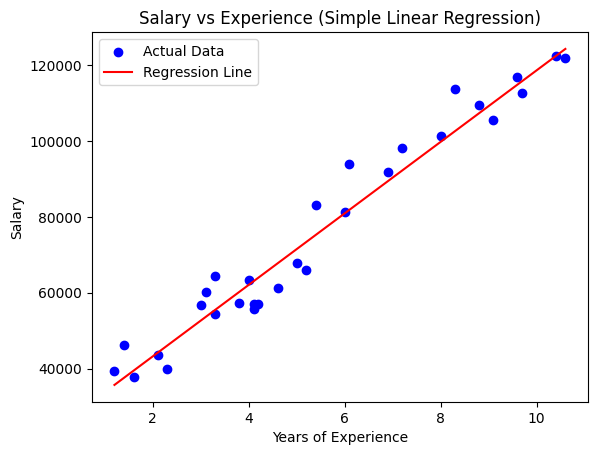

In [15]:
# Step 8: Plot Regression Line
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience (Simple Linear Regression)')
plt.legend()
plt.show()

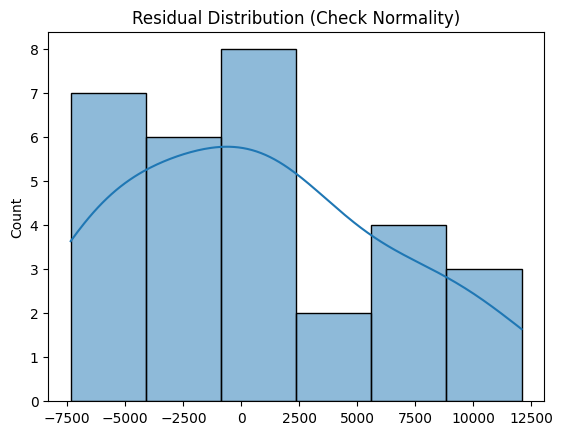

Shapiro-Wilk p-value: 0.2034
 Residuals are approximately normal.


In [17]:
# Step 9: Model Diagnostics
y_pred = model.predict(X)
residuals = Y - y_pred

# Normality of Errors
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Check Normality)")
plt.show()

shapiro_test = shapiro(residuals)
print(f"Shapiro-Wilk p-value: {shapiro_test.pvalue:.4f}")
if shapiro_test.pvalue > 0.05:
    print(" Residuals are approximately normal.")
else:
    print(" Residuals deviate from normality.")

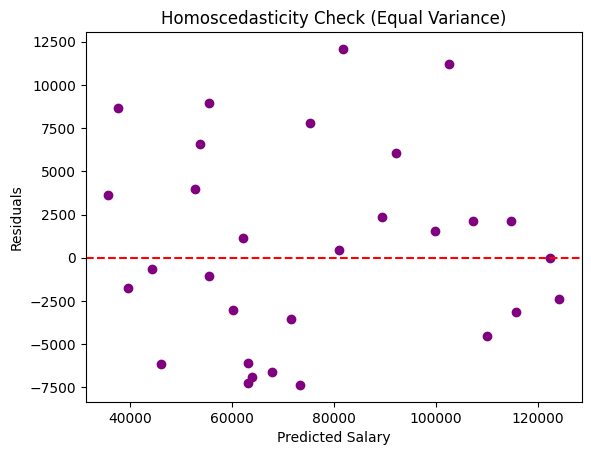

In [18]:
#  Homoscedasticity
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Salary')
plt.ylabel('Residuals')
plt.title('Homoscedasticity Check (Equal Variance)')
plt.show()

In [19]:
# Independence of Errors (Durbin-Watson)
X_sm = sm.add_constant(X)
ols_model = sm.OLS(Y, X_sm).fit()
dw_stat = sm.stats.stattools.durbin_watson(ols_model.resid)
print(f"Durbin-Watson Statistic: {dw_stat:.2f}")
if 1.5 < dw_stat < 2.5:
    print(" Errors are independent.")
else:
    print(" Possible autocorrelation in errors.")

Durbin-Watson Statistic: 1.65
 Errors are independent.


In [20]:
print("\nModel Summary:")
print(ols_model.summary())


Model Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Thu, 09 Oct 2025   Prob (F-statistic):           1.14e-20
Time:                        19:19:07   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.485e+04   2306.654    

In [22]:
import pickle as pkl

In [23]:
with open('salary_prediction.pkl','wb') as f:
    pkl.dump((model), f)